<a href="https://colab.research.google.com/github/zpempera/Customer-Segmentation-Data-Driven-Communication-Strategy/blob/main/Customer_Segmentation_%26_Data_Driven_Communication_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Customer Segmentation & Data-Driven Communication Strategy

**Author:** Zofia Pempera

---

### Project Overview

A retail company has collected two years of customer data but lacks an analytical
framework to use it. This notebook performs a complete end-to-end analysis on the
`marketing_campaign.csv` dataset:

- **Task A — Data Audit & Quality:** missing values, duplicates, type inconsistencies, outlier handling.
- **Task B — Exploratory Data Analysis:** socio-demographic drivers of spending, purchase channels, hidden promotional trends.
- **Task C — RFM Segmentation:** engineering Recency / Frequency / Monetary features, quintile scoring, heuristic segments.
- **Task D — Unsupervised Learning:** K-Means clustering, optimal-k selection (Elbow / Silhouette), comparison with RFM.
- **Task E — Communication Strategy:** recommended channel and message tone per segment.

The goal is to identify high-value customer segments and drive a data-driven communication strategy.

In [1]:
# --- Core data handling ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine learning ---
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- Display & warnings ---
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)   # show all columns
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42  # for reproducible clustering

Libraries imported successfully.


In [3]:
# Data import

DATA_URL = "https://raw.githubusercontent.com/zpempera/Customer-Segmentation-Data-Driven-Communication-Strategy/main/marketing_campaign.csv"

df = pd.read_csv(DATA_URL, sep="\;")

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset loaded: 2240 rows × 27 columns


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,"58,138.00",0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,"46,344.00",1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,"71,613.00",0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,"26,646.00",1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,"58,293.00",1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0


##Data Audit & Quality

Before any analysis we inspect the dataset's integrity. We check the structure and data
types, count missing values, look for duplicate records, and examine the numeric ranges
to spot impossible or extreme values. Each cleaning decision is documented inline so the
reasoning behind every drop, imputation, or transformation is transparent.


In [4]:
# General structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
# Missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

# Duplicate rows (full duplicates) and duplicate customer IDs
print(f"\nFully duplicated rows: {df.duplicated().sum()}")
print(f"Duplicated customer IDs: {df['ID'].duplicated().sum()}")

Columns with missing values:
Income    24
dtype: int64

Fully duplicated rows: 0
Duplicated customer IDs: 0


### Handling missing values

Only `Income` contains missing values (24 out of 2240 rows, roughly 1%). Because this is
a very small fraction of the dataset and income is a key socio-demographic variable for
spending analysis, imputing it (e.g. with the mean or median) would introduce artificial
values into one of our most important features. Given how few rows are affected, dropping
them is the safer choice.

In [7]:
rows_before = df.shape[0]

# Drop the 24 rows with missing Income (~1% of the data)
df = df.dropna(subset=["Income"]).reset_index(drop=True)

rows_after = df.shape[0]
print(f"Rows removed: {rows_before - rows_after}")
print(f"Rows remaining: {rows_after}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")

Rows removed: 24
Rows remaining: 2216
Remaining missing values: 0


In [9]:
# Descriptive statistics to spot impossible or extreme values
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,TotalSpending
count,"2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00","2,216.00"
mean,"5,588.35","1,968.82","52,247.25",0.44,0.51,49.01,305.09,26.36,167.00,37.64,27.03,43.97,2.32,4.09,2.67,5.80,5.32,0.07,0.07,0.07,0.06,0.01,0.01,0.15,607.08
std,"3,249.38",11.99,"25,173.08",0.54,0.54,28.95,337.33,39.79,224.28,54.75,41.07,51.82,1.92,2.74,2.93,3.25,2.43,0.26,0.26,0.26,0.24,0.12,0.10,0.36,602.90
min,0.00,"1,893.00","1,730.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00
25%,"2,814.75","1,959.00","35,303.00",0.00,0.00,24.00,24.00,2.00,16.00,3.00,1.00,9.00,1.00,2.00,0.00,3.00,3.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,69.00
50%,"5,458.50","1,970.00","51,381.50",0.00,0.00,49.00,174.50,8.00,68.00,12.00,8.00,24.50,2.00,4.00,2.00,5.00,6.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,396.50
75%,"8,421.75","1,977.00","68,522.00",1.00,1.00,74.00,505.00,33.00,232.25,50.00,33.00,56.00,3.00,6.00,4.00,8.00,7.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"1,048.00"
max,"11,191.00","1,996.00","666,666.00",2.00,2.00,99.00,"1,493.00",199.00,"1,725.00",259.00,262.00,321.00,15.00,27.00,28.00,13.00,20.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,"2,525.00"


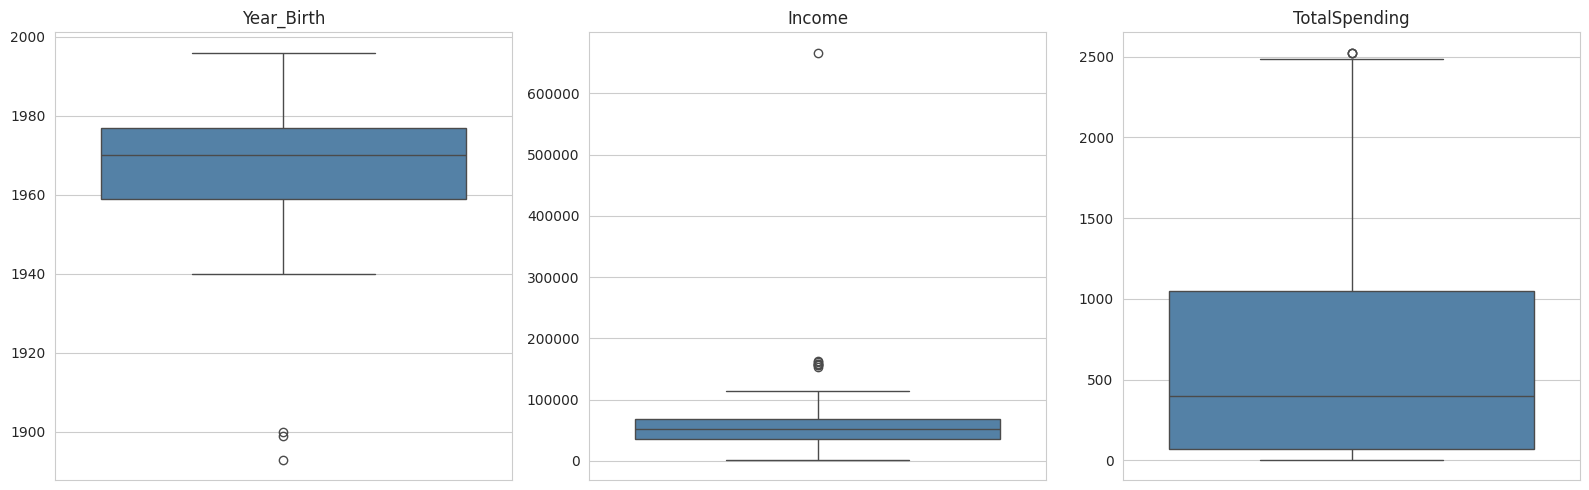

In [8]:


# Total spending across all product categories, used throughout the analysis
mnt_cols = ["MntWines", "MntFruits", "MntMeatProducts",
            "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df["TotalSpending"] = df[mnt_cols].sum(axis=1)

cols_to_check = ["Year_Birth", "Income", "TotalSpending"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, cols_to_check):
    sns.boxplot(y=df[col], ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Handling outliers

Two variables contain genuine anomalies. `Year_Birth` has a minimum of 1893, implying
customers over 95 years old, which is almost certainly a data-entry error; we remove
everyone born before 1930. `Income` has a maximum of 666,666, an extreme value far
detached from the 75th percentile (~68,500) that would distort any spending or clustering
model; we treat it as an outlier and remove it.

The high maxima in the spending and purchase-count columns are not treated as outliers:
they represent real high-value customers, which are precisely the segment we want to
identify, so removing them would discard the most valuable signal in the data.

In [10]:
rows_before = df.shape[0]

# Remove implausible birth years (customers born before 1930)
df = df[df["Year_Birth"] >= 1930]

# Remove the extreme income outlier (single value of 666,666)
df = df[df["Income"] < 600000]

df = df.reset_index(drop=True)

rows_after = df.shape[0]
print(f"Rows removed: {rows_before - rows_after}")
print(f"Rows remaining: {rows_after}")
print(f"\nYear_Birth range: {df['Year_Birth'].min()} – {df['Year_Birth'].max()}")
print(f"Income range: {df['Income'].min():,.0f} – {df['Income'].max():,.0f}")

Rows removed: 4
Rows remaining: 2212

Year_Birth range: 1940 – 1996
Income range: 1,730 – 162,397


### Feature preparation and encoding

Several columns are not yet usable for analysis. `Dt_Customer` is stored as text, so we
convert it to a datetime and derive customer tenure (days since enrolment, relative to
the most recent enrolment date in the dataset). We also engineer a few intuitive
features: `Age`, total number of children at home, and total number of purchases across
all channels.

`Marital_Status` contains inconsistent or nonsensical categories (e.g. "YOLO", "Absurd",
"Alone"), which we collapse into two clean groups, Partner and Single. Finally, the
categorical variables `Education` and `Marital_Status` are one-hot encoded so they can be
used by distance-based and machine-learning models later on.

In [12]:
# Convert enrolment date from text to datetime
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%Y-%m-%d")

# Customer tenure: days since enrolment, relative to the latest enrolment in the data
reference_date = df["Dt_Customer"].max()
df["Customer_Tenure"] = (reference_date - df["Dt_Customer"]).dt.days

# Age relative to the most recent year in the dataset
reference_year = df["Dt_Customer"].dt.year.max()
df["Age"] = reference_year - df["Year_Birth"]

# Total children living at home
df["Children"] = df["Kidhome"] + df["Teenhome"]

# Total purchases across all channels
df["TotalPurchases"] = (df["NumWebPurchases"] + df["NumCatalogPurchases"]
                        + df["NumStorePurchases"] + df["NumDealsPurchases"])

print(df[["Dt_Customer", "Customer_Tenure", "Age", "Children", "TotalPurchases"]].head())

  Dt_Customer  Customer_Tenure  Age  Children  TotalPurchases
0  2012-09-04              663   57         0              25
1  2014-03-08              113   60         2               6
2  2013-08-21              312   49         0              21
3  2014-02-10              139   30         1               8
4  2014-01-19              161   33         1              19


In [13]:
#marital status simplyfying

# Inspect the raw categories first
print("Marital_Status before cleaning:")
print(df["Marital_Status"].value_counts())

# Collapse into two clean groups
partner = ["Married", "Together"]
df["Marital_Status"] = df["Marital_Status"].apply(
    lambda x: "Partner" if x in partner else "Single"
)

print("\nMarital_Status after cleaning:")
print(df["Marital_Status"].value_counts())

Marital_Status before cleaning:
Marital_Status
Married     857
Together    571
Single      470
Divorced    231
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Marital_Status after cleaning:
Marital_Status
Partner    1428
Single      784
Name: count, dtype: int64


In [14]:
#one hot encoding

# Inspect Education categories
print("Education categories:")
print(df["Education"].value_counts())

# One-hot encode the categorical variables
df_encoded = pd.get_dummies(df, columns=["Education", "Marital_Status"],
                            drop_first=True)

print(f"\nShape after encoding: {df_encoded.shape}")
df_encoded.head()

Education categories:
Education
Graduation    1115
PhD            480
Master         365
2n Cycle       198
Basic           54
Name: count, dtype: int64

Shape after encoding: (2212, 35)


,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,TotalSpending,Customer_Tenure,Age,Children,TotalPurchases,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Single
0,5524,1957,"58,138.00",0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,1617,663,57,0,25,False,True,False,False,True
1,2174,1954,"46,344.00",1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,27,113,60,2,6,False,True,False,False,True
2,4141,1965,"71,613.00",0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,776,312,49,0,21,False,True,False,False,False
3,6182,1984,"26,646.00",1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,53,139,30,1,8,False,True,False,False,False
4,5324,1981,"58,293.00",1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,422,161,33,1,19,False,False,False,True,False


## Exploratory Data Analysis

With clean data in place, we explore the relationships that matter for marketing. First
we measure how socio-demographic features relate to total spending, then we look at how
purchases are split across sales channels, and finally we surface a less obvious trend
that could power a targeted promotional campaign.

### Socio-demographic features vs. total spending

We correlate the main socio-demographic variables (income, age, children at home) with
total spending to understand who the high-value customers are.

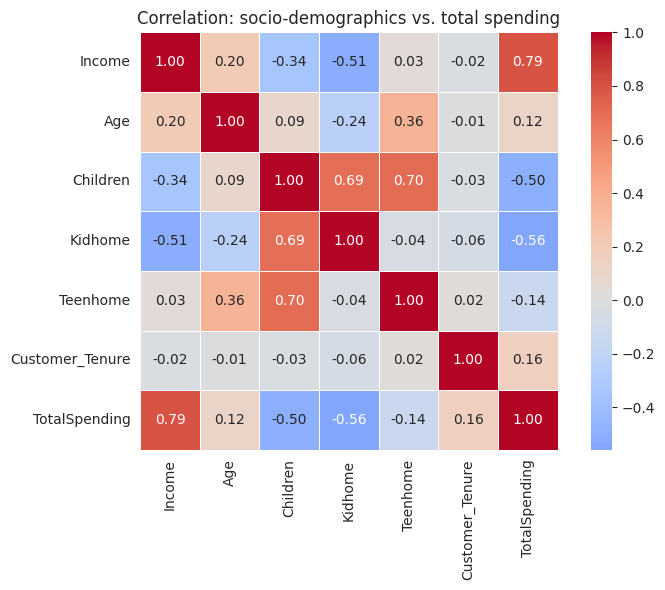

In [18]:
socio_cols = ["Income", "Age", "Children", "Kidhome", "Teenhome",
              "Customer_Tenure", "TotalSpending"]

corr = df[socio_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            square=True, linewidths=0.5)
plt.title("Correlation: socio-demographics vs. total spending")
plt.tight_layout()
plt.show()

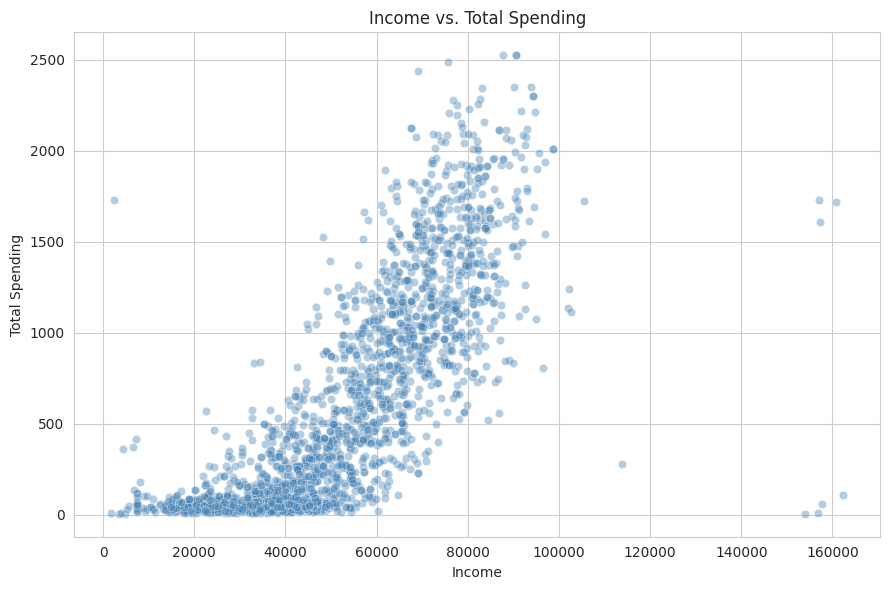

In [17]:
# Income
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Income", y="TotalSpending", alpha=0.4, color="steelblue")
plt.title("Income vs. Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.show()

### EDA summary and communication insight

The correlation analysis confirms that **income is by far the strongest driver of
spending** (r = 0.79), while the presence of children, especially young children, pulls
spending down (Kidhome r = -0.56, Children r = -0.50). Age and tenure have almost no
relationship with how much a customer spends.

The hidden trend worth acting on is the link between **young children, lower income, and
lower spending**: Kidhome is negatively correlated with income (-0.51), so households
with small children are simultaneously lower-earning and lower-spending, and they lean
more on discount purchases. This defines a clear, addressable segment: budget-conscious
families who respond to value-oriented offers. A targeted promotional campaign of
family-relevant bundles and coupons aimed at this group can lift their otherwise low
basket size, while premium messaging is better reserved for the high-income, child-free
customers who already drive most of the revenue.

## RFM Calculation & Heuristic Segmentation

We build the classic RFM framework using the three features already prepared:

- **Recency** — the `Recency` column (days since last purchase); lower is better.
- **Frequency** — `TotalPurchases`, the total number of purchases across all channels.
- **Monetary** — `TotalSpending`, the total amount spent across all categories.

Each customer is scored from 1 to 5 on each dimension using quintiles, and the three
scores are combined to define interpretable customer segments.

In [19]:
# Assemble the RFM table from existing features
rfm = df[["ID", "Recency", "TotalPurchases", "TotalSpending"]].copy()
rfm.columns = ["ID", "Recency", "Frequency", "Monetary"]

print(rfm.describe())
rfm.head()

             ID  Recency  Frequency  Monetary
count  2,212.00 2,212.00   2,212.00  2,212.00
mean   5,585.16    49.02      14.89    607.27
std    3,247.52    28.94       7.67    602.51
min        0.00     0.00       0.00      5.00
25%    2,814.75    24.00       8.00     69.00
50%    5,454.50    49.00      15.00    397.00
75%    8,418.50    74.00      21.00  1,048.00
max   11,191.00    99.00      44.00  2,525.00


,ID,Recency,Frequency,Monetary
0,5524,58,25,1617
1,2174,38,6,27
2,4141,26,21,776
3,6182,26,8,53
4,5324,94,19,422


### Quintile scoring

We assign scores from 1 to 5 based on quintiles. For Recency the logic is reversed: a
smaller number of days since the last purchase is better, so the most recent customers
receive the highest score. Frequency and Monetary follow the natural order, where higher
values earn higher scores.

In [20]:
# Recency: lower is better -> reversed scoring (labels 5..1)
rfm["R_Score"] = pd.qcut(rfm["Recency"], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency: higher is better. rank() breaks ties so qcut finds 5 clean edges
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"),
                         q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary: higher is better
rfm["M_Score"] = pd.qcut(rfm["Monetary"], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

rfm.head()

,ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,5524,58,25,1617,3,5,5,13
1,2174,38,6,27,4,1,1,6
2,4141,26,21,776,4,4,4,12
3,6182,26,8,53,4,2,1,7
4,5324,94,19,422,1,4,3,8


### Defining segments

We translate the scores into four actionable segments based on the combined RFM score and
the recency/frequency behaviour:

- **Champions** — recent, frequent, high-spending customers (the core to retain).
- **Loyal** — solid, regular customers who buy often but are not top spenders.
- **At Risk** — previously good customers who have not purchased recently.
- **Lost / Low-Value** — low across all dimensions; minimal recent engagement.

In [21]:
def assign_segment(row):
    # Recent + frequent + high spend
    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champions"
    # Buys often and recently enough, but not top spender
    elif row["F_Score"] >= 3 and row["R_Score"] >= 3:
        return "Loyal"
    # Used to be valuable but has gone quiet
    elif row["R_Score"] <= 2 and row["M_Score"] >= 3:
        return "At Risk"
    # Everything else: low engagement / low value
    else:
        return "Lost / Low-Value"

rfm["Segment"] = rfm.apply(assign_segment, axis=1)

print(rfm["Segment"].value_counts())

Segment
Lost / Low-Value    886
At Risk             540
Loyal               508
Champions           278
Name: count, dtype: int64


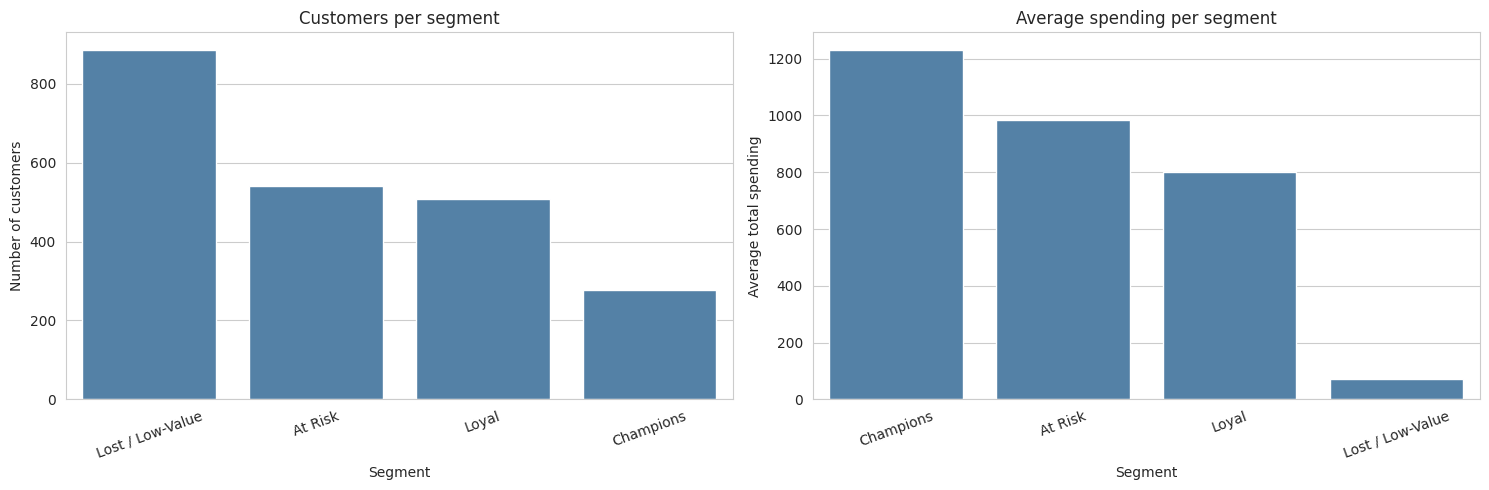

In [22]:
seg_counts = rfm["Segment"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=seg_counts.index, y=seg_counts.values, ax=axes[0], color="steelblue")
axes[0].set_title("Customers per segment")
axes[0].set_ylabel("Number of customers")
axes[0].tick_params(axis="x", rotation=20)

# Average monetary value per segment to confirm the segments make sense
seg_monetary = rfm.groupby("Segment")["Monetary"].mean().sort_values(ascending=False)
sns.barplot(x=seg_monetary.index, y=seg_monetary.values, ax=axes[1], color="steelblue")
axes[1].set_title("Average spending per segment")
axes[1].set_ylabel("Average total spending")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Unsupervised Learning (Cluster Analysis)

The heuristic RFM segments rely on fixed quintile rules. K-Means instead lets the data
define the groupings. We cluster customers on the same three dimensions (Recency,
Frequency, Monetary), choose the optimal number of clusters with the Elbow Method and the
Silhouette Score, and then compare the resulting clusters against the RFM segments.

### Scaling the features

K-Means relies on Euclidean distance, so features must be on the same scale. Monetary
runs into the thousands while Recency is bounded around 0–99; without standardisation
Monetary would dominate the distance calculation. We standardise all three features to
mean 0 and unit variance.

In [23]:
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

print("Scaled feature means (≈0):", rfm_scaled.mean(axis=0).round(2))
print("Scaled feature stds  (≈1):", rfm_scaled.std(axis=0).round(2))

Scaled feature means (≈0): [ 0. -0.  0.]
Scaled feature stds  (≈1): [1. 1. 1.]


### Choosing the optimal number of clusters

We run K-Means for k from 2 to 10 and track two diagnostics: inertia (within-cluster sum
of squares) for the Elbow Method, and the average Silhouette Score for cluster
separation. The elbow shows where adding clusters stops reducing inertia meaningfully,
while the silhouette peaks at the most cleanly separated solution.

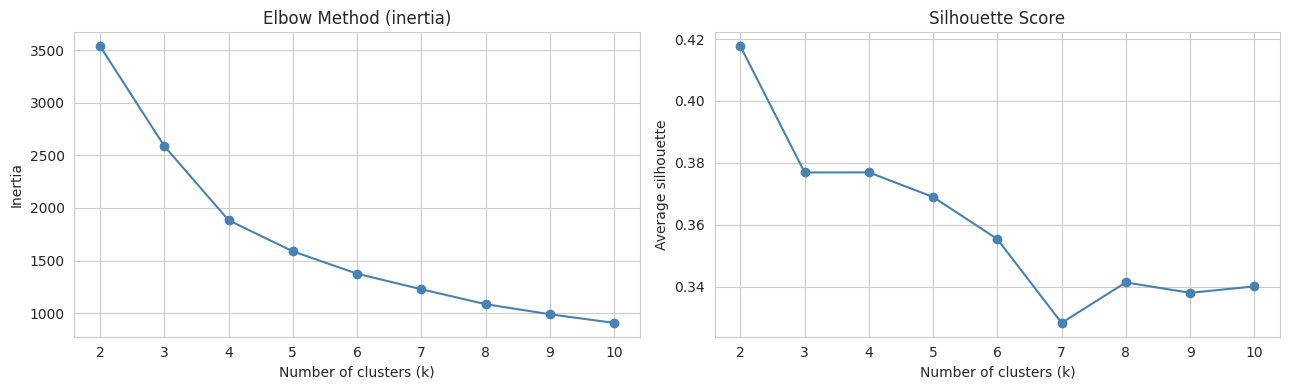

k=2: silhouette=0.418
k=3: silhouette=0.377
k=4: silhouette=0.377
k=5: silhouette=0.369
k=6: silhouette=0.355
k=7: silhouette=0.328
k=8: silhouette=0.341
k=9: silhouette=0.338
k=10: silhouette=0.340


In [25]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), inertias, marker="o", color="steelblue")
axes[0].set_title("Elbow Method (inertia)")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouettes, marker="o", color="steelblue")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Average silhouette")

plt.tight_layout()
plt.show()

for k, s in zip(k_range, silhouettes):
    print(f"k={k}: silhouette={s:.3f}")

### Selecting k = 4

The silhouette score is highest at k = 2, but that solution only separates customers into
"high value" and "low value", which is too coarse to drive a differentiated marketing
strategy. The Elbow Method shows a clear bend at k = 4, after which additional clusters
barely reduce inertia, and the silhouette at k = 4 (0.377) is essentially tied with k = 3
while remaining solid. We therefore choose k = 4, which also lets us compare the clusters
directly against the four RFM segments.

In [26]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print(rfm["Cluster"].value_counts().sort_index())

Cluster
0    494
1    572
2    604
3    542
Name: count, dtype: int64


### Profiling the clusters

To interpret what each cluster represents, we look at the average Recency, Frequency, and
Monetary values per cluster. This tells us whether a cluster corresponds to high-value
loyalists, dormant customers, newcomers, and so on.

In [27]:
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
cluster_profile["Count"] = rfm["Cluster"].value_counts().sort_index()
print(cluster_profile.round(1))

         Recency  Frequency  Monetary  Count
Cluster                                     
0          23.10      22.00  1,141.50    494
1          74.60       8.90    134.60    572
2          24.40       8.80    134.30    604
3          73.00      21.50  1,146.20    542


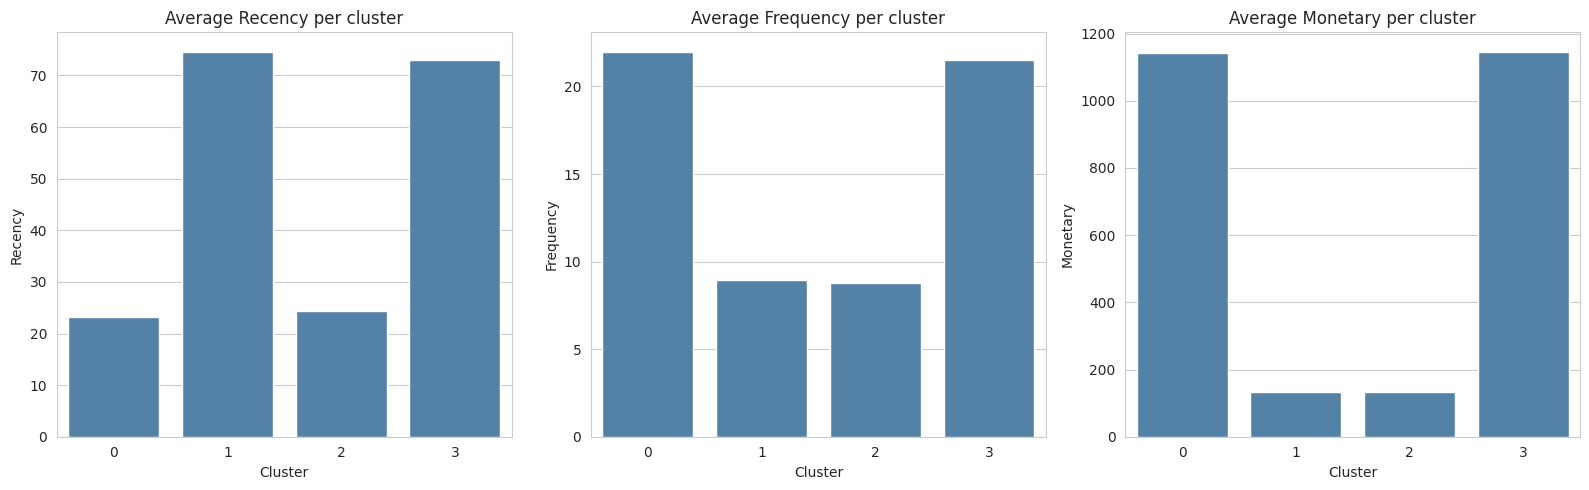

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.barplot(data=rfm, x="Cluster", y=metric, ax=ax, color="steelblue", errorbar=None)
    ax.set_title(f"Average {metric} per cluster")
plt.tight_layout()
plt.show()

### Comparing clusters with RFM segments

Finally we cross-tabulate the K-Means clusters against the heuristic RFM segments to see
how much they overlap and what the data-driven clusters capture that the rule-based
segments might miss.

Cluster             0    1    2    3
Segment                             
At Risk             0  114    0  426
Champions         278    0    0    0
Lost / Low-Value    1  428  457    0
Loyal             215   30  147  116


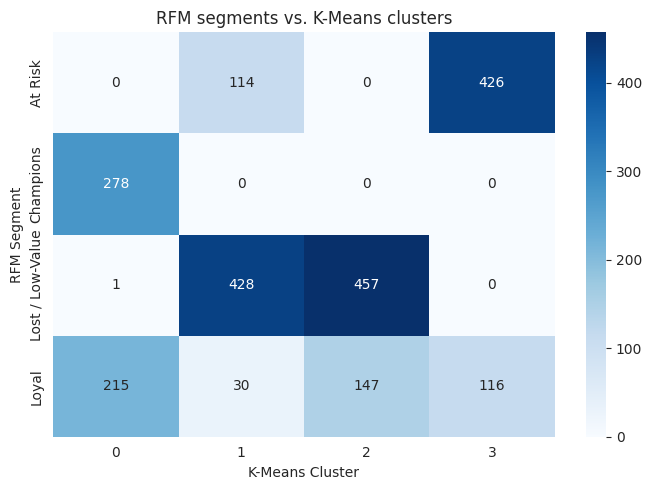

In [30]:
overlap = pd.crosstab(rfm["Segment"], rfm["Cluster"])
print(overlap)

plt.figure(figsize=(7, 5))
sns.heatmap(overlap, annot=True, fmt="d", cmap="Blues")
plt.title("RFM segments vs. K-Means clusters")
plt.xlabel("K-Means Cluster")
plt.ylabel("RFM Segment")
plt.tight_layout()
plt.show()

### Interpretation: overlap and added value

The cluster profiles reveal that K-Means separates customers primarily by **recency**.
The most valuable insight concerns the large "Lost / Low-Value" RFM segment: RFM treats
these 886 customers as one block, but K-Means splits them into two behaviourally distinct
groups. Cluster 2 ("Newcomers / Low-Spend") are recent buyers (24 days) who simply spend
little yet — a group worth nurturing toward higher value. Cluster 1 ("Hibernating") are
genuinely dormant (75 days) and low value — a low-priority group. A fixed-quintile
heuristic cannot see this difference because it only sums scores; the clustering shows
that the same low monetary value means very different things depending on how recently the
customer engaged.

In [31]:
cluster_names = {
    0: "Best Customers (recent, frequent, high spend)",
    1: "Hibernating (lapsed, low value)",
    2: "Newcomers / Low-Spend (recent, but low value)",
    3: "At Risk High-Value (lapsed, but valuable)",
}
rfm["Cluster_Name"] = rfm["Cluster"].map(cluster_names)

print(rfm["Cluster_Name"].value_counts())

Cluster_Name
Newcomers / Low-Spend (recent, but low value)    604
Hibernating (lapsed, low value)                  572
At Risk High-Value (lapsed, but valuable)        542
Best Customers (recent, frequent, high spend)    494
Name: count, dtype: int64


## Communication Strategy

We base the communication strategy on the four K-Means clusters rather than the heuristic
RFM segments. The clustering refined the RFM view, in particular by separating the
low-value customers into a recent "Newcomers" group and a dormant "Hibernating" group, so
acting on the clusters means acting on the most accurate segmentation we produced. For
each cluster we recommend a communication channel and a message tone aligned with the
customers' value and engagement.

In [32]:
strategy = pd.DataFrame({
    "Cluster": [
        "Best Customers",
        "At Risk High-Value",
        "Newcomers / Low-Spend",
        "Hibernating",
    ],
    "Profile": [
        "Recent, frequent, high spend",
        "Lapsed but historically valuable",
        "Recent but low spend",
        "Lapsed and low value",
    ],
    "Channel": [
        "Email + exclusive loyalty app/club",
        "Personalised email + catalog",
        "Web / social retargeting",
        "Low-cost email (or suppress)",
    ],
    "Message Tone": [
        "Premium, appreciative, VIP rewards",
        "Win-back, 'we miss you', strong incentive",
        "Welcoming, educational, cross-sell to grow basket",
        "Light reactivation; minimal spend, do not over-invest",
    ],
})

strategy

,Cluster,Profile,Channel,Message Tone
0,Best Customers,"Recent, frequent, high spend",Email + exclusive loyalty app/club,"Premium, appreciative, VIP rewards"
1,At Risk High-Value,Lapsed but historically valuable,Personalised email + catalog,"Win-back, 'we miss you', strong incentive"
2,Newcomers / Low-Spend,Recent but low spend,Web / social retargeting,"Welcoming, educational, cross-sell to grow basket"
3,Hibernating,Lapsed and low value,Low-cost email (or suppress),"Light reactivation; minimal spend, do not over..."


### Rationale

- **Best Customers** drive most of the revenue and are already engaged, so the goal is
  retention, not acquisition. A premium, appreciative tone and an exclusive loyalty
  programme protect this relationship without wasting budget on discounts they do not
  need.

- **At Risk High-Value** customers used to spend heavily but have gone quiet. They justify
  the highest marketing investment per head: a personalised win-back message with a
  meaningful incentive aims to recover a large amount of lost value before it is gone for
  good.

- **Newcomers / Low-Spend** customers are recent and active but spend little. The
  opportunity is growth: welcoming, educational communication and cross-sell offers can
  lift their basket size over time and graduate them toward the Best Customers group.

- **Hibernating** customers are both lapsed and low value. They warrant only low-cost
  reactivation attempts; over-investing here delivers poor return, so budget is better
  directed at the three groups above.